# Case Study Overview: Cross-Strategy Summary

**ML4T Third Edition - Chapter 6: Strategy Definition**

**Docker image**: `ml4t`

This notebook provides a unified view of all 9 case studies used throughout this book.
It consolidates key information that readers need to understand:

- **What datasets we cover**: Asset classes, universes, and time periods
- **Trading setup constraints**: Cost models, horizons, and feasibility analysis
- **Evaluation protocols**: Walk-forward configurations and holdout policies
- **Prediction coverage**: Calendar-year spans for training, validation, and holdout

**Book Reference**: Chapter 6, Sections 6.3 and 6.5

**Prerequisites**: Each case study must have a `config/setup.yaml` defining
the trading setup, universe, evaluation protocol, and cost model.

In [1]:
"""Case Study Overview: Cross-strategy summary for Chapter 6."""

import warnings
from typing import Any

import matplotlib.pyplot as plt
import polars as pl
import yaml
from matplotlib.patches import Patch

from utils.paths import REPO_ROOT

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

In [3]:
CASE_STUDIES_DIR = REPO_ROOT / "case_studies"

## Load Results

Each case study's `config/setup.yaml` defines the trading setup, universe,
evaluation protocol, and cost model. We load all available configs and build
comparative tables from them.

In [4]:
# Display names and chapter tracks — book-structural metadata, not per-run data
DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto Perps Funding",
    "nasdaq100_microstructure": "NASDAQ-100 Microstructure",
    "sp500_equity_option_analytics": "S&P 500 Equity+Options",
    "us_firm_characteristics": "US Firm Characteristics",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities Panel",
}

CHAPTER_TRACKS = {
    "etfs": "Ch6 to Ch21",
    "crypto_perps_funding": "Ch6 to Ch12",
    "nasdaq100_microstructure": "Ch6 to Ch12",
    "sp500_equity_option_analytics": "Ch6 to Ch21",
    "us_firm_characteristics": "Ch6 to Ch14",
    "fx_pairs": "Ch6 to Ch17",
    "cme_futures": "Ch6 to Ch17",
    "sp500_options": "Ch6 to Ch21",
    "us_equities_panel": "Ch6 to Ch14",
}

In [5]:
def _fmt_window(value: Any) -> Any:
    """Normalize an evaluation-window string for display.

    A few configs (fx_pairs) write ISO-8601 durations like ``P5Y``/``P1Y``;
    strip the leading ``P`` so the quick-reference table reads uniformly
    (``5Y``/``1Y``) alongside the bare ``8Y``/``6M`` values used elsewhere.
    """
    if isinstance(value, str) and len(value) > 1 and value[0] in ("P", "p"):
        return value[1:]
    return value


def _normalize_setup_yaml(case_id: str, cfg: dict) -> dict:
    """Convert setup.yaml structure to the summary/diagnostics format the notebook expects."""
    universe = cfg.get("universe", {})
    decision = cfg.get("decision", {})
    costs = cfg.get("costs", {})
    ev = cfg.get("evaluation", {})
    mapping = cfg.get("mapping", {})

    n_assets = universe.get("n_assets", 0) or universe.get("n_products", 0)
    if not n_assets:
        n_assets = len(universe.get("assets", universe.get("symbols", [])))

    # Decision cadence — case studies use different keys: `cadence`,
    # `entry_cadence` (sp500_options), or `bar_frequency` (microstructure).
    cadence = (
        decision.get("cadence")
        or decision.get("entry_cadence")
        or decision.get("bar_frequency")
        or ""
    )
    freq_map = {
        "monthly_month_end": "Daily",
        "8_hour_funding_aligned": "8-hourly",
        "daily_close": "Daily",
        "daily_ny_close": "Daily",
        "weekly_friday_close": "Weekly",
        "weekly_friday": "Weekly",
        "15_minute": "15-min",
        "15_min": "15-min",
    }
    data_freq = freq_map.get(cadence, cadence)

    holdout_start = ev.get("holdout_start", "")
    holdout_end = ev.get("holdout_end", "")

    return {
        "summary": {
            "asset_class": _infer_asset_class(case_id),
            "universe_size": n_assets,
            "data_frequency": data_freq,
            "decision_cadence": cadence.replace("_", " "),
            "cost_model": costs.get("class", "").title(),
        },
        "diagnostics": {
            "train_size": _fmt_window(ev.get("train_size", "N/A")),
            "test_size": _fmt_window(ev.get("val_size", "N/A")),
            "n_splits": ev.get("n_splits", 0),
            "holdout_start": holdout_start,
            "holdout_end": holdout_end,
        },
        "techniques": {
            "setup_type": mapping.get("class", ""),
            "position_mapping": mapping.get("entry_logic", ""),
        },
    }

### Infer Asset Class

In [6]:
def _infer_asset_class(case_id: str) -> str:
    """Infer asset class from case study ID."""
    mapping = {
        "etfs": "Multi-Asset",
        "crypto_perps_funding": "Crypto",
        "nasdaq100_microstructure": "Equities",
        "sp500_equity_option_analytics": "Equities+Options",
        "us_firm_characteristics": "Equities",
        "fx_pairs": "FX",
        "cme_futures": "Futures",
        "sp500_options": "Options",
        "us_equities_panel": "Equities",
    }
    return mapping.get(case_id, "Unknown")

### Load All Case Study Configs

In [7]:
def load_setup_results() -> dict[str, dict]:
    """Load config/setup.yaml from all case studies."""
    results = {}
    for case_dir in sorted(CASE_STUDIES_DIR.iterdir()):
        if case_dir.name.startswith("_") or not case_dir.is_dir():
            continue
        setup_path = case_dir / "config" / "setup.yaml"
        if not setup_path.exists():
            continue
        cfg = yaml.safe_load(setup_path.read_text())
        results[case_dir.name] = _normalize_setup_yaml(case_dir.name, cfg)
    return results

In [8]:
all_results = load_setup_results()
print(f"Loaded results for {len(all_results)}/{len(DISPLAY_NAMES)} case studies")

if len(all_results) < len(DISPLAY_NAMES):
    missing = set(DISPLAY_NAMES) - set(all_results)
    print(f"Missing: {', '.join(sorted(missing))}")

Loaded results for 9/9 case studies


## Helper: Window Conversion

In [9]:
def _window_to_years(value: Any) -> float | None:
    """Convert window spec to years.

    Supports numeric trading days or strings like 6M, 2Q, 10D, 26W, 1Y.
    """
    if value is None:
        return None
    if isinstance(value, (int, float)):
        return float(value) / 252.0
    if isinstance(value, str):
        s = value.strip().upper()
        if s.startswith("P"):  # ISO 8601 duration prefix used by some configs
            s = s[1:]
        try:
            if s.endswith("Y"):
                return float(s[:-1])
            if s.endswith("Q"):
                return float(s[:-1]) * 0.25
            if s.endswith("M"):
                return float(s[:-1]) / 12.0
            if s.endswith("W"):
                return float(s[:-1]) / 52.0
            if s.endswith("D"):
                return float(s[:-1]) / 252.0
        except ValueError:
            return None
    return None

---

## 1. Case Study Inventory

The book uses 9 case studies that span different asset classes, frequencies,
and time horizons. This diversity demonstrates how the same ML4T workflow
adapts to different trading contexts.

In [10]:
overview_rows = []
for case_id, r in all_results.items():
    s = r.get("summary", {})
    overview_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(case_id, case_id),
            "Asset Class": s.get("asset_class", ""),
            "Universe": s.get("universe_size", 0),
            "Data Freq": s.get("data_frequency", ""),
            "Decision": s.get("decision_cadence", ""),
            "Cost Model": s.get("cost_model", ""),
        }
    )

overview_df = pl.DataFrame(overview_rows)
overview_df

Case Study,Asset Class,Universe,Data Freq,Decision,Cost Model
str,str,i64,str,str,str
"""CME Futures""","""Futures""",30,"""Weekly""","""weekly friday close""","""Material"""
"""Crypto Perps Funding""","""Crypto""",19,"""8-hourly""","""8 hour funding aligned""","""Material"""
"""ETFs""","""Multi-Asset""",100,"""Daily""","""monthly month end""","""Material"""
"""FX Pairs""","""FX""",20,"""Daily""","""daily ny close""","""Material"""
"""NASDAQ-100 Microstructure""","""Equities""",114,"""15-min""","""15 minute""","""Dominant"""
"""S&P 500 Equity+Options""","""Equities+Options""",633,"""Weekly""","""weekly friday close""","""Material"""
"""S&P 500 Options""","""Options""",627,"""Weekly""","""weekly friday""","""Dominant"""
"""US Equities Panel""","""Equities""",3199,"""Daily""","""daily close""","""Material"""
"""US Firm Characteristics""","""Equities""",2500,"""Daily""","""monthly month end""","""Material"""


**What to notice**:
- Universe sizes range widely: from 19 (Crypto) and 20 (FX) through the low
  hundreds (ETFs 100, NASDAQ-100 114, the S&P 500 option books ~600-630) up to
  the multi-thousand equity panels (US Firm Characteristics ~2,500, US Equities
  Panel 3,199) - a span that reshapes cross-sectional signal construction
- Data frequencies span 15-minute bars (NASDAQ-100) to weekly (CME Futures, S&P 500)
- Cost models are either "Material" (7 case studies) or "Dominant" (2),
  where dominant costs require exceptionally strong signals

### Asset Class Distribution

In [11]:
asset_counts: dict[str, int] = {}
for r in all_results.values():
    ac = r.get("summary", {}).get("asset_class", "Unknown")
    asset_counts[ac] = asset_counts.get(ac, 0) + 1

asset_df = pl.DataFrame(
    [
        {"Asset Class": ac, "Count": count}
        for ac, count in sorted(asset_counts.items(), key=lambda x: -x[1])
    ]
)
asset_df

Asset Class,Count
str,i64
"""Equities""",3
"""Futures""",1
"""Crypto""",1
"""Multi-Asset""",1
"""FX""",1
"""Equities+Options""",1
"""Options""",1


**What to notice**:
- Equities dominate (3 pure + 1 hybrid), reflecting their importance in ML4T
- "Equities+Options" is a hybrid: trades equities using options-derived features
- Each non-equity asset class (Crypto, FX, Futures, Options, Multi-Asset) has
  one dedicated case study showing unique mechanics

---

## 2. Evaluation Protocol Summary

Each case study defines a walk-forward evaluation protocol. The key parameters are:
- **Training window**: How much history to use for model fitting
- **Test window**: Validation fold duration
- **Holdout period**: Sealed data for final confirmation

In [12]:
protocol_rows = []
for case_id, r in all_results.items():
    d = r.get("diagnostics", {})
    ho_s = d.get("holdout_start", "?")
    ho_e = d.get("holdout_end", "?")
    protocol_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(case_id, case_id),
            "Train": d.get("train_size", "N/A"),
            "Test": d.get("test_size", "N/A"),
            "Folds": d.get("n_splits", 0),
            "Holdout": f"{ho_s}-{ho_e}",
        }
    )

protocol_df = pl.DataFrame(protocol_rows)
protocol_df

Case Study,Train,Test,Folds,Holdout
str,str,str,i64,str
"""CME Futures""","""8Y""","""1Y""",5,"""2024-01-01-2025-12-31"""
"""Crypto Perps Funding""","""2Y""","""1Y""",2,"""2024-01-01-2025-12-31"""
"""ETFs""","""10Y""","""1Y""",8,"""2024-01-01-2025-12-31"""
"""FX Pairs""","""5Y""","""1Y""",8,"""2024-01-01-2025-12-31"""
"""NASDAQ-100 Microstructure""","""6M""","""6M""",2,"""2021-07-01-2021-12-31"""
"""S&P 500 Equity+Options""","""2Y""","""1Y""",2,"""2021-01-01-2021-12-31"""
"""S&P 500 Options""","""2Y""","""1Y""",2,"""2021-01-01-2021-12-31"""
"""US Equities Panel""","""10Y""","""1Y""",16,"""2016-01-01-2018-03-31"""
"""US Firm Characteristics""","""10Y""","""1Y""",10,"""2016-01-01-2016-12-31"""


**What to notice**:
- Training windows range from 6M (microstructure) to 10Y (firm characteristics),
  reflecting both data availability and stationarity assumptions
- Fold counts vary from 2 (shorter histories: crypto, microstructure, options) to 16 (US equities)
- All case studies have a sealed holdout; this discipline is non-negotiable

---

## 3. Cost Model and Horizon Feasibility

Trading costs constrain viable horizons. This section summarizes the cost-horizon
analysis from each setup notebook.

### Cost Model Classes

| Class | Description | Implication |
|-------|-------------|-------------|
| **Dominant** | Costs are first-order; small edges live near the spread | Need very strong predictability; costs dominate feasibility |
| **Material** | Costs affect profitability but don't rule out trading | Horizon choice depends on signal decay vs cost hurdle |

The **dominant** cost regime (NASDAQ-100 microstructure, S&P 500 options) requires
unusually strong signals to overcome friction.

In [13]:
cost_rows = []
for case_id, r in all_results.items():
    s = r.get("summary", {})
    cost_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(case_id, case_id),
            "Cost Class": s.get("cost_model", ""),
            "Decision Cadence": s.get("decision_cadence", ""),
        }
    )

cost_df = pl.DataFrame(cost_rows)
cost_df

Case Study,Cost Class,Decision Cadence
str,str,str
"""CME Futures""","""Material""","""weekly friday close"""
"""Crypto Perps Funding""","""Material""","""8 hour funding aligned"""
"""ETFs""","""Material""","""monthly month end"""
"""FX Pairs""","""Material""","""daily ny close"""
"""NASDAQ-100 Microstructure""","""Dominant""","""15 minute"""
"""S&P 500 Equity+Options""","""Material""","""weekly friday close"""
"""S&P 500 Options""","""Dominant""","""weekly friday"""
"""US Equities Panel""","""Material""","""daily close"""
"""US Firm Characteristics""","""Material""","""monthly month end"""


**What to notice**:
- FX majors have the tightest spreads (1-3 bps per leg; crosses 3-8 bps),
  enabling daily horizons — see `case_studies/fx_pairs/config/setup.yaml`
- Options spreads are wide relative to premium (2-5%), making costs the binding constraint
- Horizon choice aligns with cost: higher costs push toward longer holding periods

---

## 4. Prediction Coverage Across Case Studies

This figure shows the calendar-year data spans for all 9 case studies,
highlighting training, validation, and holdout periods.

### Compute Coverage

In [14]:
def compute_coverage(results: dict[str, dict]) -> list[dict]:
    """Compute prediction coverage spans from results JSON data."""
    coverage_data = []

    for case_id, r in results.items():
        d = r.get("diagnostics", {})

        holdout_start = d.get("holdout_start")
        holdout_end = d.get("holdout_end")
        try:
            holdout_start_year = int(str(holdout_start)[:4]) if holdout_start else None
            holdout_end_year = int(str(holdout_end)[:4]) if holdout_end else None
        except (ValueError, TypeError):
            continue

        if holdout_start_year is None or holdout_end_year is None:
            continue

        n_splits = d.get("n_splits", 5)
        test_size = d.get("test_size", "1Y")

        test_years = _window_to_years(test_size)
        if test_years is None:
            test_years = 1.0

        val_span = n_splits * test_years
        val_start_year = holdout_start_year - val_span

        # Training starts before validation by the training window size
        train_size = d.get("train_size", "1Y")
        train_years = _window_to_years(train_size)
        if train_years is None:
            train_years = 1.0
        data_start_year = val_start_year - train_years

        coverage_data.append(
            {
                "id": case_id,
                "name": DISPLAY_NAMES.get(case_id, case_id),
                "data_start": data_start_year,
                "val_start": val_start_year,
                "holdout_start": holdout_start_year,
                "holdout_end": holdout_end_year,
            }
        )

    coverage_data.sort(key=lambda x: (x["data_start"], x["name"]))
    return coverage_data

In [15]:
case_studies_coverage = compute_coverage(all_results)

### Coverage Figure

In [16]:
def plot_coverage(coverage_data):
    """Plot prediction coverage spans as horizontal stacked bars."""
    fig, ax = plt.subplots(figsize=(12, 5.5))
    bar_height = 0.65

    for i, cs in enumerate(coverage_data):
        y = len(coverage_data) - 1 - i

        ax.barh(
            y,
            cs["val_start"] - cs["data_start"],
            left=cs["data_start"],
            height=bar_height,
            color="0.3",
            edgecolor="white",
            linewidth=0.5,
        )
        ax.barh(
            y,
            cs["holdout_start"] - cs["val_start"],
            left=cs["val_start"],
            height=bar_height,
            color="0.55",
            edgecolor="white",
            linewidth=0.5,
        )
        ax.barh(
            y,
            cs["holdout_end"] - cs["holdout_start"] + 1,
            left=cs["holdout_start"],
            height=bar_height,
            color="0.8",
            edgecolor="white",
            linewidth=0.5,
        )

    ax.set_yticks(range(len(coverage_data)))
    ax.set_yticklabels([cs["name"] for cs in reversed(coverage_data)])
    ax.set_ylim(-0.7, len(coverage_data) - 0.3)

    min_year = min(cs["data_start"] for cs in coverage_data) - 2
    max_year = max(cs["holdout_end"] for cs in coverage_data) + 2
    ax.set_xlim(min_year, max_year)
    ax.set_xlabel("Year")
    ax.tick_params(left=False)

    legend_elements = [
        Patch(facecolor="0.3", label="Training"),
        Patch(facecolor="0.55", label="Validation"),
        Patch(facecolor="0.8", label="Holdout (sealed)"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True,
        fancybox=False,
        edgecolor="gray",
    )
    ax.set_title("Prediction Coverage Across Case Studies")
    fig.show()

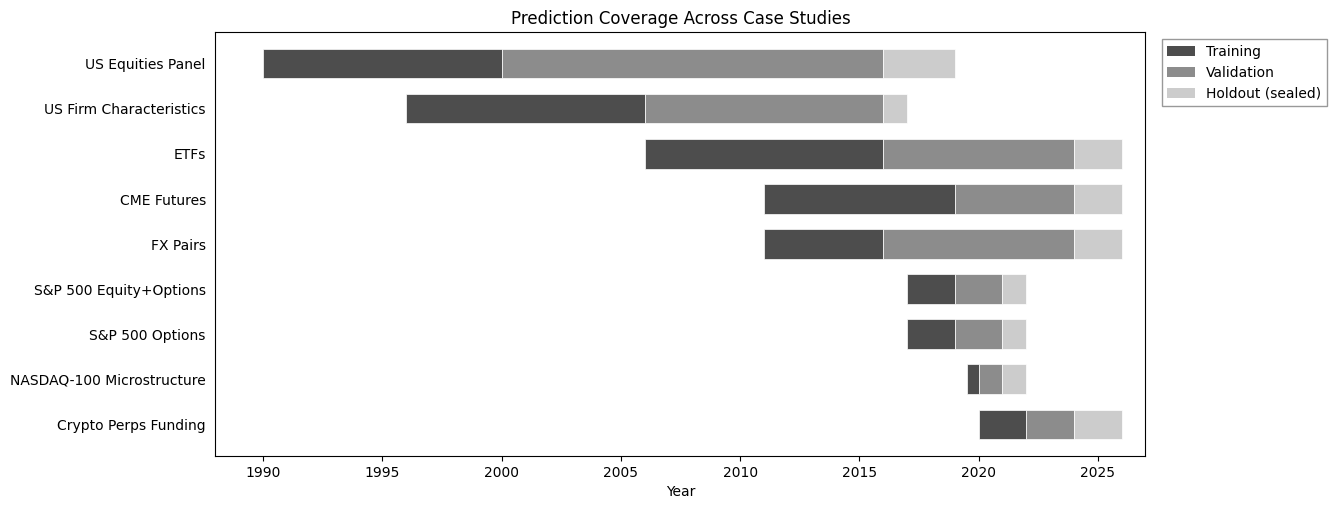

In [17]:
if case_studies_coverage:
    plot_coverage(case_studies_coverage)
else:
    print("No coverage data available. Run setup notebooks first.")

### Coverage Statistics (Computed)

In [18]:
if case_studies_coverage:
    earliest_start = min(cs["data_start"] for cs in case_studies_coverage)
    latest_end = max(cs["holdout_end"] for cs in case_studies_coverage)
    max_span = latest_end - earliest_start

    longest_val = max(cs["holdout_start"] - cs["val_start"] for cs in case_studies_coverage)
    shortest_val = min(cs["holdout_start"] - cs["val_start"] for cs in case_studies_coverage)

    holdout_lengths = [cs["holdout_end"] - cs["holdout_start"] + 1 for cs in case_studies_coverage]
    max_holdout = max(holdout_lengths)
    min_holdout = min(holdout_lengths)

    recent_datasets = [cs["name"] for cs in case_studies_coverage if cs["data_start"] >= 2020]
    long_datasets = [cs["name"] for cs in case_studies_coverage if cs["data_start"] <= 1995]

    print(f"Coverage spans {int(earliest_start)} to {int(latest_end)} ({int(max_span)} years)")
    print(f"Validation periods: {shortest_val:.0f} to {longest_val:.0f} years")
    print(f"Holdout periods: {min_holdout} to {max_holdout} years")
    print(f"Recent datasets (2020+): {', '.join(recent_datasets) if recent_datasets else 'None'}")
    print(
        f"Long-history datasets (pre-1995): {', '.join(long_datasets) if long_datasets else 'None'}"
    )

Coverage spans 1990 to 2025 (35 years)
Validation periods: 1 to 16 years
Holdout periods: 1 to 3 years
Recent datasets (2020+): Crypto Perps Funding
Long-history datasets (pre-1995): US Equities Panel


**Interpretation** (computed from results):

The coverage statistics above show the actual data spans. Key observations:
- **Longest histories** (US Equities, Firm Characteristics) provide deep validation
  but may include regime changes that affect stationarity
- **Recent datasets** (Crypto, Microstructure) limit walk-forward depth but
  reflect current market conditions
- **Holdout variation** reflects data availability: options data ends 2021,
  constraining holdout to 1 year vs 2 years for other case studies

---

## 5. Quick Reference Table

This table consolidates key information for quick reference when working
with any case study in the book.

In [19]:
reference_rows = []
for case_id, r in all_results.items():
    s = r.get("summary", {})
    d = r.get("diagnostics", {})

    ho_s = d.get("holdout_start", "?")
    ho_e = d.get("holdout_end", "?")

    reference_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(case_id, case_id),
            "Asset": s.get("asset_class", ""),
            "N": s.get("universe_size", 0),
            "Freq": s.get("data_frequency", ""),
            "Cost": s.get("cost_model", "")[:3],
            "Train": d.get("train_size", "N/A"),
            "Folds": d.get("n_splits", 0),
            "Holdout": f"{ho_s}-{ho_e}",
            "Track": CHAPTER_TRACKS.get(case_id, ""),
        }
    )

reference_df = pl.DataFrame(reference_rows)
reference_df

Case Study,Asset,N,Freq,Cost,Train,Folds,Holdout,Track
str,str,i64,str,str,str,i64,str,str
"""CME Futures""","""Futures""",30,"""Weekly""","""Mat""","""8Y""",5,"""2024-01-01-2025-12-31""","""Ch6 to Ch17"""
"""Crypto Perps Funding""","""Crypto""",19,"""8-hourly""","""Mat""","""2Y""",2,"""2024-01-01-2025-12-31""","""Ch6 to Ch12"""
"""ETFs""","""Multi-Asset""",100,"""Daily""","""Mat""","""10Y""",8,"""2024-01-01-2025-12-31""","""Ch6 to Ch21"""
"""FX Pairs""","""FX""",20,"""Daily""","""Mat""","""5Y""",8,"""2024-01-01-2025-12-31""","""Ch6 to Ch17"""
"""NASDAQ-100 Microstructure""","""Equities""",114,"""15-min""","""Dom""","""6M""",2,"""2021-07-01-2021-12-31""","""Ch6 to Ch12"""
"""S&P 500 Equity+Options""","""Equities+Options""",633,"""Weekly""","""Mat""","""2Y""",2,"""2021-01-01-2021-12-31""","""Ch6 to Ch21"""
"""S&P 500 Options""","""Options""",627,"""Weekly""","""Dom""","""2Y""",2,"""2021-01-01-2021-12-31""","""Ch6 to Ch21"""
"""US Equities Panel""","""Equities""",3199,"""Daily""","""Mat""","""10Y""",16,"""2016-01-01-2018-03-31""","""Ch6 to Ch14"""
"""US Firm Characteristics""","""Equities""",2500,"""Daily""","""Mat""","""10Y""",10,"""2016-01-01-2016-12-31""","""Ch6 to Ch14"""


**What to notice**:
- "Track" column shows which chapters use each case study, enabling readers
  to follow specific datasets through the book
- Dominant-cost case studies (NASDAQ-100, Options) have shorter tracks,
  reflecting their specialized, educational role
- Material-cost case studies carry through to later chapters (Ch14, Ch17, Ch21)

### Column Descriptions

| Column | Description |
|--------|-------------|
| **N** | Universe size (number of tradable assets) |
| **Freq** | Native data frequency |
| **Cost** | Cost model class (Dom=Dominant, Mat=Material) |
| **Train** | Training window size |
| **Folds** | Number of walk-forward validation folds |
| **Holdout** | Sealed holdout period years |
| **Track** | Chapter sequence where this case study appears |

---

## 6. Setup Techniques Summary

How each case study maps signals to positions:

In [20]:
technique_rows = []
for case_id, r in all_results.items():
    t = r.get("techniques", {})
    technique_rows.append(
        {
            "Case Study": DISPLAY_NAMES.get(case_id, case_id),
            "Setup Type": t.get("setup_type", ""),
            "Position Mapping": t.get("position_mapping", ""),
        }
    )

technique_df = pl.DataFrame(technique_rows)
technique_df

Case Study,Setup Type,Position Mapping
str,str,str
"""CME Futures""","""long_short_carry_rank""","""rank_by_carry_or_momentum"""
"""Crypto Perps Funding""","""long_short_funding_aligned""","""threshold_or_rank_based"""
"""ETFs""","""long_only_rank_and_rebalance""","""rank_selection_top_n"""
"""FX Pairs""","""long_short_rank_rebalance""","""rank_by_momentum_or_carry"""
"""NASDAQ-100 Microstructure""","""intraday_rank_and_trade""","""rank_or_threshold"""
"""S&P 500 Equity+Options""","""long_only_rank_and_rebalance""","""rank_by_iv_signal"""
"""S&P 500 Options""","""systematic_straddle_sell""","""sell_atm_straddle_weekly"""
"""US Equities Panel""","""long_short_decile_rebalance""","""decile_sort_long_top_short_bot…"
"""US Firm Characteristics""","""long_short_decile_rebalance""","""decile_sort_long_top_short_bot…"


---

## Key Takeaways

1. **Diversity by design**: The 9 case studies span equities, crypto, FX, futures,
   options, and multi-asset ETFs, demonstrating ML4T workflow adaptability.

2. **Cost models matter**: The cost regime (dominant vs material) determines
   viable horizons. Microstructure and options strategies face dominant costs
   that require exceptionally strong signals.

3. **Protocol heterogeneity**: Training windows range from 6 months (microstructure)
   to 10 years (firm characteristics), reflecting data availability and
   stationarity assumptions.

4. **Holdout discipline**: All case studies reserve a sealed holdout period that
   is never used for development decisions. This discipline is essential for
   honest performance estimation.

5. **Coverage varies**: Historical depth ranges from recent (2020+ for crypto)
   to decades (1990 for US equities), affecting the reliability
   of walk-forward estimates.

**Next**: Individual setup notebooks (`case_studies/*/01_feasibility_analysis.py`) contain
the detailed trading setup and evaluation protocol for each case study.